LINEAR REGRESSION ALOGOTITHM:


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
data = pd.read_excel("/content/house_price_prediction_practice_dataset.xlsx")

In [ ]:
data['Bathrooms'] = data['Bathrooms'].fillna(data['Bathrooms'].mean())
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HouseID       1000 non-null   int64  
 1   Date          1000 non-null   object 
 2   Bedrooms      1000 non-null   int64  
 3   Bathrooms     1000 non-null   float64
 4   Sqft_Living   1000 non-null   int64  
 5   Sqft_Lot      1000 non-null   int64  
 6   Floors        1000 non-null   int64  
 7   Waterfront    1000 non-null   int64  
 8   View          1000 non-null   int64  
 9   Condition     1000 non-null   int64  
 10  Grade         1000 non-null   int64  
 11  YearBuilt     1000 non-null   int64  
 12  Neighborhood  975 non-null    object 
 13  GarageCars    1000 non-null   int64  
 14  Age           1000 non-null   int64  
 15  Price         1000 non-null   int64  
dtypes: float64(1), int64(13), object(2)
memory usage: 125.1+ KB


In [ ]:
x = data.drop(columns=['Price'])
y= data['Price']

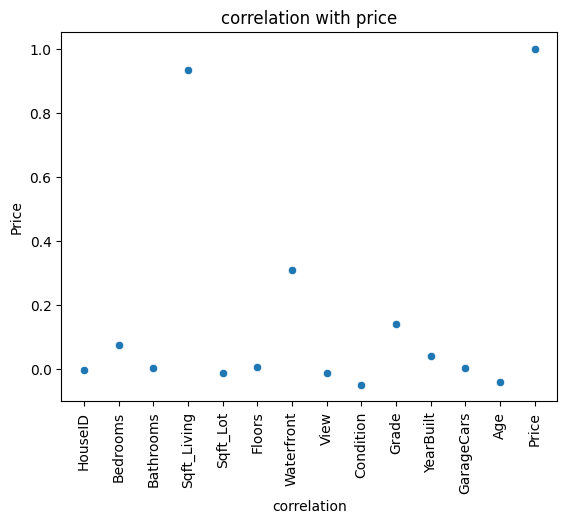

In [ ]:
# checking correalation with the target column using plot
corr_target = data.corr(numeric_only=True)['Price']
sns.scatterplot(corr_target)
plt.title('correlation with price')
plt.xlabel('correlation')
plt.xticks(rotation=90)
plt.show()

In [ ]:
data.head()

,HouseID,Date,Bedrooms,Bathrooms,Sqft_Living,Sqft_Lot,Floors,Waterfront,View,Condition,Grade,YearBuilt,Neighborhood,GarageCars,Age,Price
0,1,2020-08-16,1,3.1,3476,8982,2,0,3,3,10,1970,Riverside,2,56,840834
1,2,2020-12-01,2,1.2,4324,2406,2,0,2,1,8,2014,Lakeside,0,12,964169
2,3,2021-12-26,6,3.4,894,5254,1,0,4,5,8,2000,Hillview,0,26,443463
3,4,2021-01-04,1,1.5,3551,6206,2,0,4,2,13,1996,Suburb,2,30,825253
4,5,2023-09-25,3,2.3,2175,5349,2,0,2,1,12,1965,Hillview,3,61,649006


In [ ]:
x = x.drop(columns=['HouseID','Date','Age','Neighborhood'])

In [ ]:
x.isnull().sum()

,0
Bedrooms,0
Bathrooms,0
Sqft_Living,0
Sqft_Lot,0
Floors,0
Waterfront,0
View,0
Condition,0
Grade,0
YearBuilt,0


In [ ]:

x

,Bedrooms,Bathrooms,Sqft_Living,Sqft_Lot,Floors,Waterfront,View,Condition,Grade,YearBuilt,GarageCars
0,1,3.1,3476,8982,2,0,3,3,10,1970,2
1,2,1.2,4324,2406,2,0,2,1,8,2014,0
2,6,3.4,894,5254,1,0,4,5,8,2000,0
3,1,1.5,3551,6206,2,0,4,2,13,1996,2
4,3,2.3,2175,5349,2,0,2,1,12,1965,3
...,...,...,...,...,...,...,...,...,...,...,...
995,3,2.5,4472,8764,1,1,4,1,3,2012,0
996,5,1.7,4026,10977,1,0,3,3,4,1999,2
997,2,3.4,2708,1771,1,0,4,3,5,1962,1
998,4,2.2,976,4867,1,0,4,4,12,2012,3


In [ ]:
cate_col = x.select_dtypes(include='object').columns

In [ ]:
cate_col

Index([], dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
x_test

array([[-0.88571955, -0.238263  ,  1.4156533 , ...,  1.01546458,
         1.57007914, -1.38296619],
       [-1.48417871, -1.52647883, -0.55359392, ..., -1.20934045,
         0.1207933 , -0.45944954],
       [-1.48417871, -1.64358936,  0.29281544, ...,  1.33329387,
        -0.25321595,  1.38758377],
       ...,
       [ 0.90965792, -1.52647883,  1.64886436, ..., -0.89151116,
        -0.67397635,  1.38758377],
       [ 0.31119876,  0.69862124,  0.977771  , ...,  0.06197671,
         0.5415537 , -0.45944954],
       [ 0.90965792,  0.58151071,  1.56324492, ...,  1.33329387,
        -0.34671826, -1.38296619]])

In [ ]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_pred = linear_model.predict(x_test)

In [ ]:
y_pred

array([1064601.4751473 ,  497611.92382903,  928574.0402953 ,
        677899.47080921,  920333.68422405,  901896.90639279,
        555160.83616944,  946856.78582222,  397410.79427101,
        776636.34819303,  882550.71035007,  605427.59925334,
        659698.43552142,  336234.28235041,  539326.9849172 ,
        701313.08986249,  903626.96129449,  503159.19954734,
        393572.7457779 ,  718202.21008692,  628789.51892441,
       1041334.27830194,  909599.07769806,  492946.44686542,
       1014524.0703691 ,  868391.32138274,  775872.39442308,
        653218.91488875, 1280411.44900904,  906921.03236156,
        998592.2502972 ,  710144.30377821,  650362.82555385,
        752428.34098323, 1214581.5539544 ,  425104.31721185,
        903623.86148692, 1061180.31585439,  374887.02821052,
       1200665.62116487,  978844.4689749 ,  928347.71102982,
        698674.53446891,  770384.35934635,  526807.8740468 ,
        625269.666382  ,  622354.12629541,  697633.96078945,
        865522.53300899,

In [ ]:
from sklearn.metrics import *

In [ ]:
r2_score(y_test,y_pred)

0.9882221407741922

DECISSION TREE ALGORITHM :


In [ ]:
from sklearn.tree import DecisionTreeRegressor
model_tree = DecisionTreeRegressor()
model_tree.fit(x_train,y_train)

DecisionTreeRegressor()

In [ ]:
y_pred_tree = model_tree.predict(x_test)

In [ ]:
y_pred_tree

array([1121675.,  496693.,  918277.,  642448., 1033723.,  888558.,
        510088.,  972530.,  389092.,  812400.,  955554.,  605910.,
        638904.,  349268.,  522304.,  745063.,  922791.,  496693.,
        388020.,  723019.,  689550., 1000158.,  921984.,  535808.,
       1015720.,  837461.,  714011.,  600849., 1164812.,  950448.,
        948921.,  747364.,  661455.,  717911., 1164812.,  432259.,
        984514., 1111582.,  390002., 1227656.,  944158.,  930952.,
        733019.,  761241.,  509154.,  536928.,  646140.,  668131.,
        881117.,  833643.,  892044.,  445463.,  842442.,  313357.,
        445576., 1210292.,  619307., 1191089.,  498149.,  444131.,
       1009112.,  611965.,  806458.,  296020.,  611965., 1237357.,
        752021., 1137851.,  385184.,  744557., 1000158.,  994085.,
        464487.,  370989.,  522769.,  547650.,  967839., 1016725.,
        672192.,  438275., 1181127.,  438275.,  964900.,  925133.,
        725057.,  780383.,  449452.,  632605.,  845652.,  9055

In [ ]:
r2_score(y_test,y_pred_tree)

0.9598724689402165

USING CORSS VALIDATION

In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(
    model_tree,
    x_train,
    y_train,
    cv=5
)
print(scores)
print(f"Avarage score :{scores.mean()}")

[0.92811698 0.91714741 0.94178653 0.94983999 0.94224626]
Avarage score :0.9358274350906257


 USING GRID SEARCH CV

In [ ]:
from sklearn.model_selection import GridSearchCV
prams = {
    'max_depth':[2,4,6,8],
    'min_samples_split':[2,4,5,6],
    'min_samples_leaf':[1,2,4,5]
}
grid = GridSearchCV(
    estimator=model_tree,
    param_grid=prams,
    cv=5,
    scoring='r2'
)
grid.fit(x_train,y_train)


GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'max_depth': [2, 4, 6, 8],
                         'min_samples_leaf': [1, 2, 4, 5],
                         'min_samples_split': [2, 4, 5, 6]},
             scoring='r2')

In [ ]:
print(f"best_r2 score : {grid.best_score_}")

best_r2 score : 0.9516703637350075


In [ ]:
best_tree_model = grid.best_estimator_

In [ ]:
best_tree_model

DecisionTreeRegressor(max_depth=8, min_samples_leaf=5)

In [ ]:
best_tree_model.fit(x_train,y_train)

DecisionTreeRegressor(max_depth=8, min_samples_leaf=5)

In [ ]:
y_pred_best_model = best_tree_model.predict(x_test)
y_pred_best_model

array([1076516.6       ,  502687.6       ,  923308.66666667,
        618760.6       ,  979695.6       ,  923308.66666667,
        517697.        , 1012128.6       ,  459438.16666667,
        771382.71428571,  916052.85714286,  619399.        ,
        672110.        ,  398317.        ,  541746.4       ,
        768061.        ,  921728.42857143,  502687.6       ,
        383731.        ,  767386.22222222,  650062.14285714,
       1029768.        ,  880958.1       ,  545285.66666667,
       1008636.44444444,  857234.6       ,  709259.        ,
        650062.14285714, 1217785.5       ,  960479.66666667,
        996029.71428571,  745360.4       ,  613874.84615385,
        727367.125     , 1217785.5       ,  416678.4       ,
        920723.        , 1088643.8       ,  398317.        ,
       1217785.5       ,  969725.8       ,  916052.85714286,
        720574.        ,  768061.        ,  517697.        ,
        571416.75      ,  603687.6       ,  709259.        ,
        840296.76190476,

In [ ]:
r2_score(y_test,y_pred_best_model)

0.9631777480156913

KNN ALOGRITHM :

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score
k_values = []
R2_score =[]
# finding the k values
for k in range(2,12):
  model_KNN = KNeighborsRegressor(n_neighbors=k)
  scores_knn = cross_val_score(
      model_KNN,
      x_train,
      y_train,
      cv=5,
      scoring='r2'
  )
  k_values.append(k)
  R2_score.append(scores_knn.mean())


In [ ]:
k_values

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

In [ ]:
R2_score


[np.float64(0.7184864648532506),
 np.float64(0.7445374455884713),
 np.float64(0.7570228196803764),
 np.float64(0.7689358128927906),
 np.float64(0.7754019187943891),
 np.float64(0.7770247320669563),
 np.float64(0.7799498321919295),
 np.float64(0.7782871337847863),
 np.float64(0.7776660900343781),
 np.float64(0.776746201223528)]

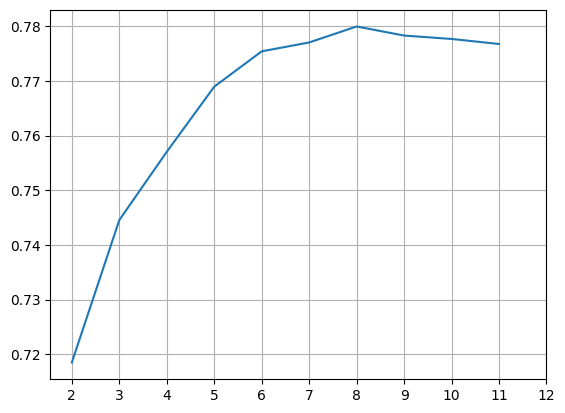

In [ ]:
plt.plot(k_values,R2_score)
plt.xticks(range(2,13))
plt.grid()
plt.show()


In [ ]:
model_KNN = KNeighborsRegressor(n_neighbors=8)
model_KNN.fit(x_train,y_train)


KNeighborsRegressor(n_neighbors=8)

In [ ]:
y_pred_KNN = model_KNN.predict(x_test)

In [ ]:
r2_score(y_test,y_pred_KNN)

0.8128932992705262

In [ ]:
# using grid search
from sklearn.model_selection import GridSearchCV

pramss = {
    'n_neighbors':[2,3,5,6,8,10],
    'weights':['uniform','distance'],
    "metric": ["euclidean", "manhattan",'minkowski']
}
grids_KNN = GridSearchCV(
    estimator=model_KNN,
    param_grid=pramss,
    cv=5,
    scoring='r2'
)
grids_KNN.fit(x_train,y_train)
print(grids_KNN.best_score_)

0.7874729013141805


In [ ]:
print(f"Best_parameters is : {grids_KNN.best_params_}")


Best_parameters is : {'metric': 'euclidean', 'n_neighbors': 8, 'weights': 'distance'}


In [ ]:
KNN_best_model = grid.best_estimator_

In [ ]:
KNN_best_model

DecisionTreeRegressor(max_depth=8, min_samples_leaf=5)

In [ ]:
y_pred_KNN_best = KNN_best_model.predict(x_test)

In [ ]:
r2_score(y_test,y_pred_KNN_best)

0.9631777480156913

SVR (SUPPORT VECTOR REGRESSION)


In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
model_SVR = SVR()
param = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto'],
    'epsilon': [0.01, 0.1, 1]
}
grid_SVR = GridSearchCV(
    estimator=model_SVR,
    param_grid=param,
    cv=5,
    scoring='r2'
)
grid_SVR.fit(x_train,y_train)
print(grid_SVR.best_score_)

0.38704128965802875


In [ ]:
best_svr_model = grid_SVR.best_estimator_

In [ ]:
best_svr_model.fit(x_train,y_train)

SVR(C=100, epsilon=1, kernel='linear')

In [ ]:
y_pred_svr = best_svr_model.predict(x_test)

In [ ]:
r2_score(y_test,y_pred_svr)

0.4742274394572853

# combine the all algorithms to take which algorithm is best

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
# for evalution

from sklearn.metrics import * # importing all evaluation metrics

In [ ]:
# writing a loop to perfrom the all machine learning algorithms
models = {
    'LinearRegression' : LinearRegression(),
    'KNeighborsRegressor' : KNeighborsRegressor(),
    'DecisionTreeRegressor' : DecisionTreeRegressor(),
    'SVR': SVR()
}

models_results = [] # stroing the values produced by models
for name,model in models.items():
  model.fit(x_train,y_train)
  y_pred_all = model.predict(x_test)
  r2_score(y_test,y_pred)
  root_mean_squared_error(y_test,y_pred_all)
  models_results.append({
      'Model':name,
      'R2score':r2_score(y_test,y_pred_all),
      'Rootmeansquarederror': root_mean_squared_error(y_test,y_pred_all)
  })

models_results


[{'Model': 'LinearRegression',
  'R2score': 0.9882221407741922,
  'Rootmeansquarederror': 28542.15224017858},
 {'Model': 'KNeighborsRegressor',
  'R2score': 0.7885361994727469,
  'Rootmeansquarederror': 120940.44307813246},
 {'Model': 'DecisionTreeRegressor',
  'R2score': 0.9574497624463693,
  'Rootmeansquarederror': 54250.59843692971},
 {'Model': 'SVR',
  'R2score': -0.00025898407729041395,
  'Rootmeansquarederror': 263032.7158355124}]

In [ ]:
import joblib
joblib.dump(models['LinearRegression'],'LinearRegression.house_predction.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(x.columns.tolist(),'columns.pkl')

['columns.pkl']

In [ ]:
x.columns

Index(['Bedrooms', 'Bathrooms', 'Sqft_Living', 'Sqft_Lot', 'Floors',
       'Waterfront', 'View', 'Condition', 'Grade', 'YearBuilt', 'GarageCars'],
      dtype='object')

In [ ]:
import os

print(os.getcwd())

/content


In [ ]:
joblib.dump(model, "house_price_model.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

In [ ]:
import os

print(os.listdir())

['.config', 'house_price_prediction_practice_dataset (1).xlsx', 'scaler.pkl', 'house_price_prediction_practice_dataset.xlsx', 'columns.pkl', 'house_price_model.pkl', 'LinearRegression.house_predction.pkl', 'sample_data']


In [ ]:
model = LinearRegression()
model.fit(x_train, y_train)

# ← Paste the next 10–15 lines after this

LinearRegression()

In [ ]:
import pickle

with open("LinearRegression.house_predction.pkl", "wb") as f:
    pickle.dump(model, f)

In [ ]:
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [ ]:
with open("x.columns.pkl", "wb") as f:
    pickle.dump(x.columns, f)

In [ ]:
from google.colab import files

files.download("LinearRegression.house_predction.pkl")
files.download("scaler.pkl")
files.download("columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
x.columns


Index(['Bedrooms', 'Bathrooms', 'Sqft_Living', 'Sqft_Lot', 'Floors',
       'Waterfront', 'View', 'Condition', 'Grade', 'YearBuilt', 'GarageCars'],
      dtype='object')